# $T_1$ Characterization
Due to decoherence processes, an excited qubit decays to its ground state after a constant $T_1$ (the coherence time). <br>
A $T_1$ experiment estimates the probability to measure $\ket{1}$ (the excited state) after $t$ $\mu s$ of delay. <br>
In the absence of state preparation and measurement errors, the probability to measure $\ket{1}$ after time $t$ is $e^{-t/{T_1}}$. But since state preparation and measurement errors do exist, we assume the form $Ae^{-t/{T_1}}+B$, for parameters $A$,$T_1$ and $B$ for probabilty estimates.

In [124]:
#import libraries
import numpy as np
from qiskit import QuantumCircuit, transpile

#Simulator
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakePerth

### Simulator Setup

In [125]:
#Create a pure relaxation noise model
noise_model = NoiseModel.from_backend(FakePerth(), thermal_relaxation=True, gate_error=False, readout_error=False)
#Create backend simulator
backend = AerSimulator.from_backend(FakePerth(), noise_model=noise_model)

### Simulator Experiment

In [126]:
#Use FakePerth's T_1
qubit0_t1 = FakePerth().qubit_properties(0).t1

#Setting waiting time intervals
delays_sim = np.arange(1e-6, 3 * qubit0_t1, 3e-5)
delays_sim=delays_sim*1e6 #change in units

#Circuit Setup
circuits_sim = []

for delay in delays_sim:
    qc_sim = QuantumCircuit(1,1)
    qc_sim.x(0)
    qc_sim.delay(delay, 0, unit="us")
    qc_sim.measure(0,0)
    circuits_sim.append(qc_sim)

job_sim = backend.run(circuits_sim, shots=100)
results_sim = job_sim.result()

### Simulation Results

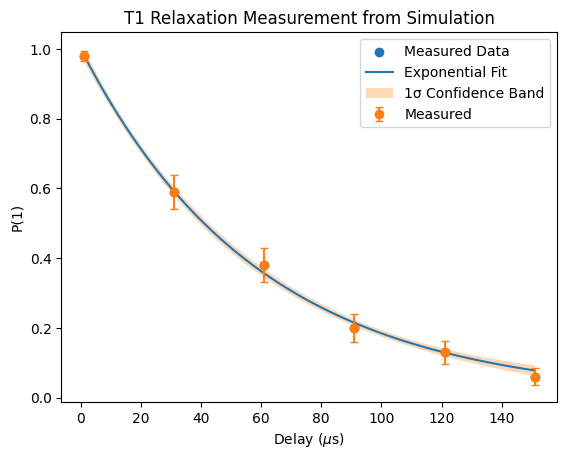


Fit Results:
A  = 0.9998
T1 = 5.912333e+01 μs
B  = 0.0000
T1 uncertainty = ±4.98e+00 μs


In [127]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

#Get probabilility for each delay
p1s = []
p1s_errs = []
for i, delay in enumerate(delays_sim):
    counts = results_sim.get_counts(i)
    shots = sum(counts.values())
    p1 = counts.get('1', 0) / shots
    p1s.append(p1)
    err = np.sqrt(p1*(1-p1)/shots) #Error
    p1s_errs.append(err)

#Ae^{-t/{T_1}}+B Model
def model(t, A, T1, B):
    return A*np.exp(-t/T1) + B

#Fit and Error evaluation
p0 = [p1s[0] - p1s[-1], (delays_sim[-1]-delays_sim[0])/3, p1s[-1]]  # decent guesses
params, cov = curve_fit(model, delays_sim, p1s, p0=p0, bounds=([0,0,0],[1,np.inf,1]))
A_fit, T1_fit, B_fit = params
T1_err = np.sqrt(cov[1,1])

# Plot Setup
t_fit = np.linspace(min(delays_sim), max(delays_sim), 200)
y_fit = model(t_fit, A_fit, T1_fit, B_fit)
fit_curve = A_fit * np.exp(-t_fit / T1_fit) + B_fit

# Compute gradient for each t
grad = np.zeros((len(t_fit), 3))

exp_term = np.exp(-t_fit / T1_fit)

grad[:,0] = exp_term                           # d/dA
grad[:,1] = A_fit * (t_fit / T1_fit**2) * exp_term  # d/dT1
grad[:,2] = 1                                  # d/dB

# Propagate covariance
sigma_curve = np.sqrt(np.einsum('ij,jk,ik->i', grad, cov, grad))
low = np.clip(y_fit - sigma_curve, 0, 1)
high = np.clip(y_fit + sigma_curve, 0, 1)

# Plot
plt.figure()
plt.scatter(delays_sim, p1s, label="Measured Data")
plt.plot(t_fit, fit_curve, label="Exponential Fit")
plt.fill_between(
    t_fit,
    low,
    high,
    alpha=0.3,
    label="1σ Confidence Band"
)
plt.errorbar(delays_sim, p1s, yerr=p1s_errs, fmt='o', capsize=3, label="Measured")
plt.xlabel(r"Delay ($\mu$s)")
plt.ylabel("P(1)")
plt.title("T1 Relaxation Measurement from Simulation")
plt.legend()
plt.show()

print("\nFit Results:")
print(f"A  = {A_fit:.4f}")
print(f"T1 = {T1_fit:.6e} μs")
print(f"B  = {B_fit:.4f}")
print(f"T1 uncertainty = ±{T1_err:.2e} μs")


### Real Backend Setup

In [128]:
#Real Backend
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

service = QiskitRuntimeService()
backend = service.backend("ibm_torino") #This is least busy when I am working on this
print("Using backend: ",backend.name)
dt = backend.configuration().dt # seconds per dt tick
print("dt (ns)      =", dt * 1e9)

management.get:WARNING:2026-02-18 21:23:10,485: Loading default saved account


Using backend:  ibm_torino
dt (ns)      = 4.0


### Experiment Setup

In [ ]:
#Setting waiting time intervals
delays = np.arange(1e-6, 3 * 400e-6, 3e-5)#Torino T1 median is approximately 185.85 us 

delay_dts = [] # apparently we have to turn our units to integers dt

#Circuit Setup
circuits = []

for delay in delays:
    d = int(round(delay / dt))          # integer dt ticks
    delay_dts.append(d)

    qc = QuantumCircuit(1,1)
    qc.x(0)
    qc.delay(d, 0, unit="dt")
    qc.measure(0,0)
    circuits.append(qc)

#Use the same physical qubit(Qubit 100)
physical = 100
transpiled = transpile(
    circuits,
    backend=backend,
    optimization_level=1,
    initial_layout=[physical],
)

sampler = Sampler(mode=backend)
job = sampler.run(circuits, shots=100)
results = job.result()

### Plot

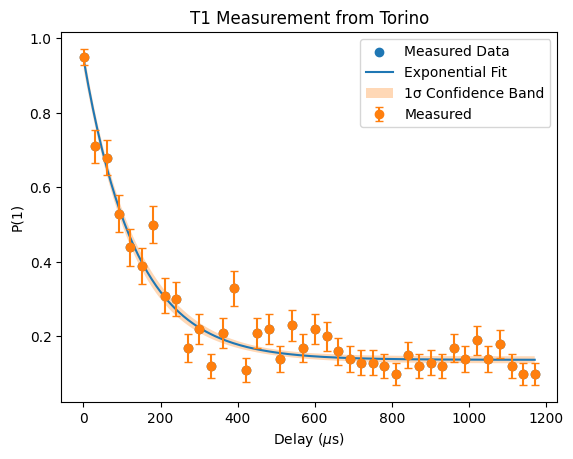


Fit Results:
A  = 0.8096
T1 = 1.342556e+02 μs
B  = 0.1374
T1 uncertainty = ±1.15e+01 μs


In [130]:
#Get probabilility for each delay
p = []
p_errs = []
delays=delays*1e6 #change in units
for i, delay in enumerate(delays):
    counts = results[i].join_data().get_counts() # merges all classical register
    shots = sum(counts.values())
    pi = counts.get('1', 0) / shots
    p.append(pi)
    err = np.sqrt(pi*(1-pi)/shots) #Error
    p_errs.append(err)

#Fit and Error evaluation
p0 = [p[0] - p[-1], (delays[-1]-delays[0])/3, p[-1]]  # decent guesses
params, cov = curve_fit(model, delays, p, p0=p0,sigma=p_errs, bounds=([0,0,0],[1,np.inf,1]))
A_fit, T1_fit, B_fit = params
T1_err = np.sqrt(cov[1,1])

# Plot Setup
t_fit = np.linspace(min(delays), max(delays), 200)
y_fit = model(t_fit, A_fit, T1_fit, B_fit)
fit_curve = A_fit * np.exp(-t_fit / T1_fit) + B_fit

# Compute gradient for each t
grad = np.zeros((len(t_fit), 3))

exp_term = np.exp(-t_fit / T1_fit)

grad[:,0] = exp_term                           # d/dA
grad[:,1] = A_fit * (t_fit / T1_fit**2) * exp_term  # d/dT1
grad[:,2] = 1                                  # d/dB

# Propagate covariance
sigma_curve = np.sqrt(np.einsum('ij,jk,ik->i', grad, cov, grad))
low = np.clip(y_fit - sigma_curve, 0, 1)
high = np.clip(y_fit + sigma_curve, 0, 1)

# Plot
plt.figure()
plt.scatter(delays, p, label="Measured Data")
plt.plot(t_fit, fit_curve, label="Exponential Fit")
plt.fill_between(
    t_fit,
    low,
    high,
    alpha=0.3,
    label="1σ Confidence Band"
)
plt.errorbar(delays, p, yerr=p_errs, fmt='o', capsize=3, label="Measured")
plt.xlabel(r"Delay ($\mu$s)")
plt.ylabel("P(1)")
plt.title("T1 Measurement from Torino")
plt.legend()
plt.show()

print("\nFit Results:")
print(f"A  = {A_fit:.4f}")
print(f"T1 = {T1_fit:.6e} μs")
print(f"B  = {B_fit:.4f}")
print(f"T1 uncertainty = ±{T1_err:.2e} μs")
